In [18]:
!pip install face-recognition opencv-python numpy matplotlib Pillow

In [19]:
from google.colab import files

uploaded = files.upload()

Saving demo.jpg.jpeg to demo.jpg (2).jpeg


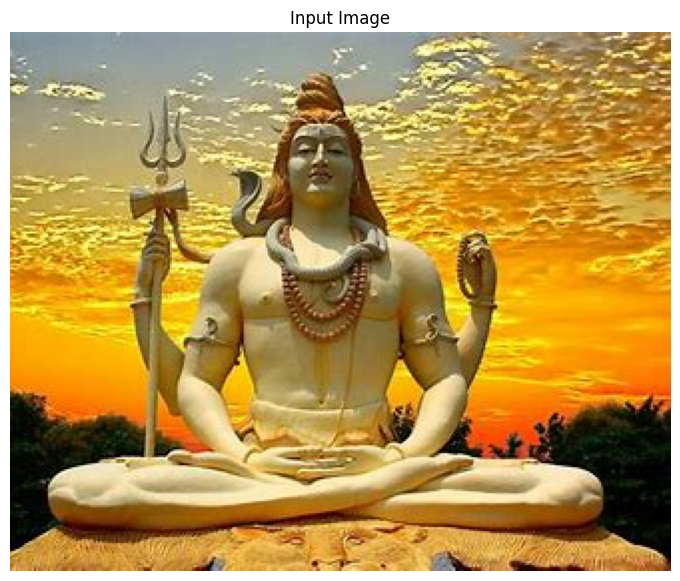

In [20]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("demo.jpg.jpeg")

if image is None:
    print("Image not found. Check the filename.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 7))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

Number of faces detected: 1


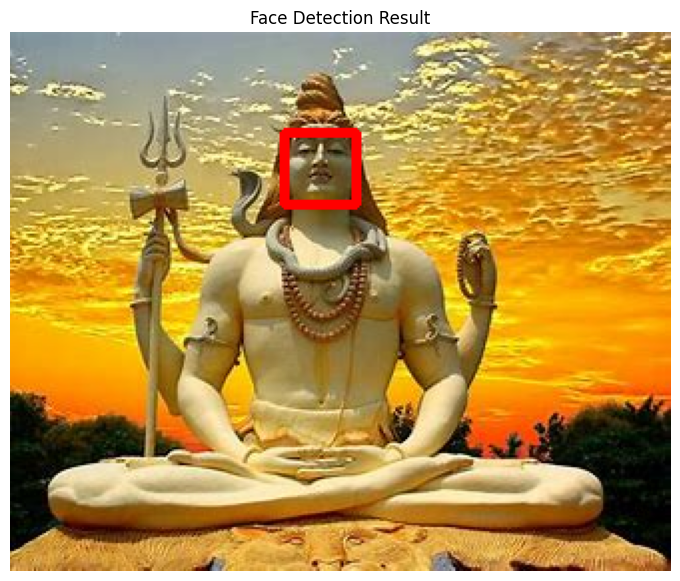

In [21]:
import face_recognition
import cv2
import matplotlib.pyplot as plt

image = face_recognition.load_image_file("demo.jpg.jpeg")

face_locations = face_recognition.face_locations(image)

print("Number of faces detected:", len(face_locations))

image_result = image.copy()

for top, right, bottom, left in face_locations:
    cv2.rectangle(
        image_result,
        (left, top),
        (right, bottom),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(10, 7))
plt.imshow(image_result)
plt.axis("off")
plt.title("Face Detection Result")
plt.show()

In [22]:
face_encodings = face_recognition.face_encodings(image)

print("Number of face encodings:", len(face_encodings))

Number of face encodings: 1


In [23]:
from google.colab import files

uploaded = files.upload()

Saving geetha.jpg to geetha (2).jpg


In [24]:
import face_recognition

known_image = face_recognition.load_image_file("geetha.jpg")

known_encodings = face_recognition.face_encodings(known_image)

if len(known_encodings) == 0:
    print("No face found in geetha.jpg")
else:
    known_encoding = known_encodings[0]
    print("Geetha's face encoding created successfully!")

Geetha's face encoding created successfully!


In [25]:
import face_recognition

matches = face_recognition.compare_faces(
    [known_encoding],
    face_encodings[0]
)

print("Match:", matches[0])

Match: False


In [29]:
geetha_image = face_recognition.load_image_file("/content/geetha.jpg")

geetha_locations = face_recognition.face_locations(geetha_image)

geetha_encodings = face_recognition.face_encodings(
    geetha_image,
    geetha_locations
)

if len(geetha_encodings) > 0:
    geetha_encoding = geetha_encodings[0]
    print("Geetha encoding created successfully!")
else:
    print("No face found in geetha.jpg")

Geetha encoding created successfully!


In [30]:
demo_encodings = face_recognition.face_encodings(
    image,
    face_locations
)

print("Demo encodings:", len(demo_encodings))

Demo encodings: 1


In [31]:
face_distance = face_recognition.face_distance(
    [geetha_encoding],
    demo_encodings[0]
)[0]

match = face_distance < 0.6

print("Match:", match)
print("Face distance:", face_distance)

Match: False
Face distance: 0.7082205557885425


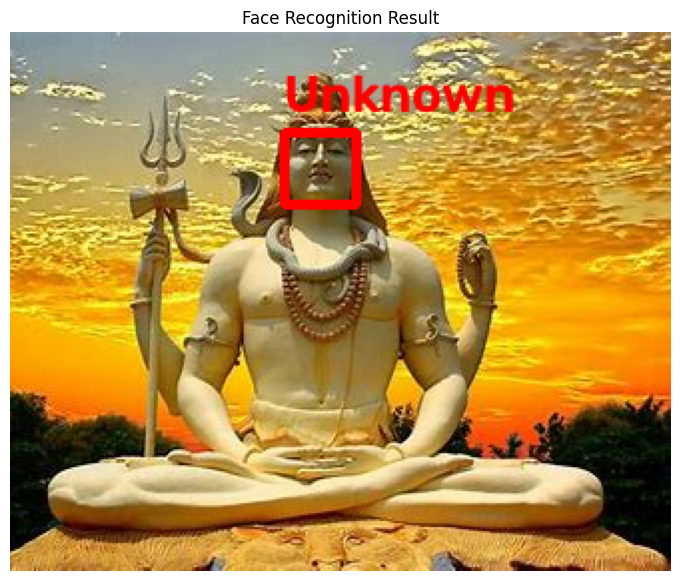

In [32]:
result = image.copy()

name = "Geetha" if match else "Unknown"

for top, right, bottom, left in face_locations:
    cv2.rectangle(
        result,
        (left, top),
        (right, bottom),
        (255, 0, 0),
        3
    )

    cv2.putText(
        result,
        name,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10, 7))
plt.imshow(result)
plt.axis("off")
plt.title("Face Recognition Result")
plt.show()

In [33]:
cv2.imwrite(
    "/content/result.png",
    cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
)

print("Result saved successfully!")

Result saved successfully!


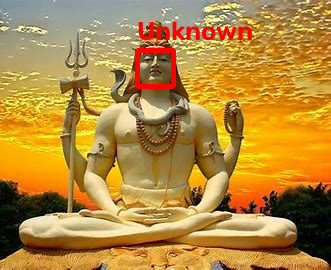

In [34]:
from IPython.display import Image, display

display(Image(filename="/content/result.png"))

In [35]:
from google.colab import files

files.download("/content/result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
from google.colab import files

files.download("/content/result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>